In [1]:
import numpy as np
import pandas as pd
import openpyxl


In [3]:
aml_fraud_customer_profiling = pd.read_csv("data/aml_fraud_customer_profiling.csv")

In [4]:
aml_fraud_customer_profiling.Risk_Label.value_counts(dropna=False)


Risk_Label
Low_Risk     1400
High_Risk     600
Name: count, dtype: int64

In [82]:
aml_fraud_customer_profiling2 = aml_fraud_customer_profiling.copy()

Top features by |correlation| with Risk_Target:
Composite_Risk_Score          0.788194
Volume_x_CountryRisk          0.622756
Country_Risk_Score            0.578347
Country_Risk_Score_Squared    0.574695
Country_Risk_Flag             0.551247
Amount_x_CountryRisk          0.466767
Name: Risk_Target, dtype: float64

Best feature used for simple sigmoid view: Composite_Risk_Score
Sigmoid: p = 1 / (1 + exp(-(-10.4436 + 17.1498*Composite_Risk_Score)))
Decision boundary (Composite_Risk_Score at p=0.5): 0.6090


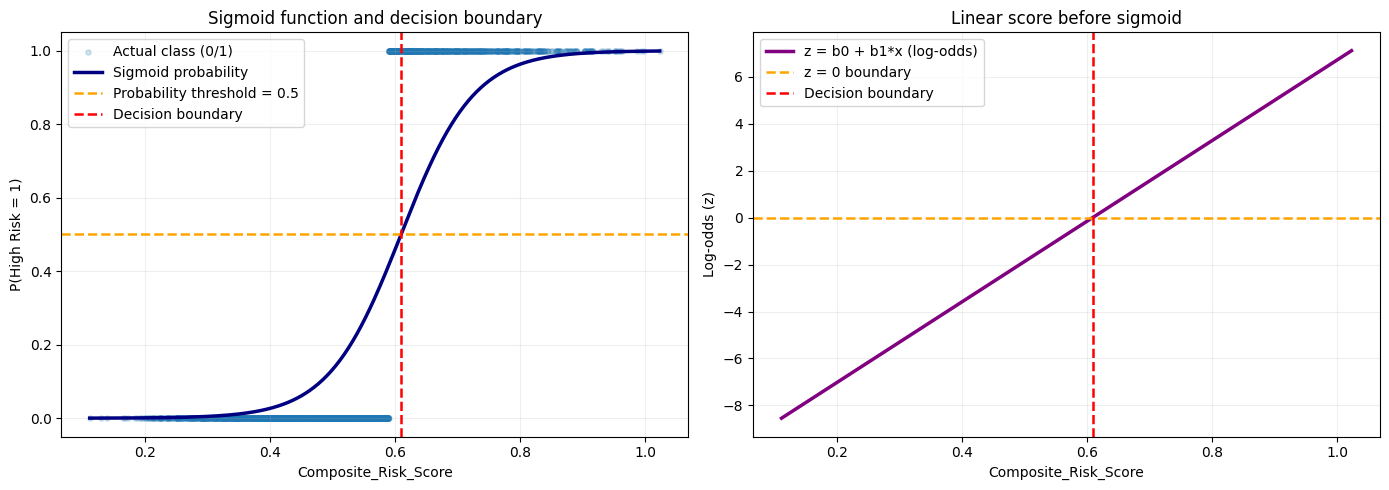


How this helps classification:
- The model first computes a linear score z = b0 + b1*x.
- Sigmoid converts z to probability between 0 and 1.
- If probability >= 0.5, classify as High_Risk (1), otherwise Low_Risk (0).
- The vertical line is the exact feature value where prediction flips class.


In [83]:
from sklearn.linear_model import LogisticRegression

# Select useful numeric features for AML risk classification
target = "Risk_Target"
num_cols = aml_fraud_customer_profiling2.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target]

corr = aml_fraud_customer_profiling2[num_cols + [target]].corr()[target].drop(target)
top_features_aml = corr.abs().sort_values(ascending=False).head(6).index.tolist()

print("Top features by |correlation| with Risk_Target:")
print(corr.loc[top_features_aml].sort_values(key=np.abs, ascending=False))

# Use the single strongest feature for a simple sigmoid explanation plot
best_feature = top_features_aml[0]
X = aml_fraud_customer_profiling2[[best_feature]].values
y = aml_fraud_customer_profiling2[target].values

import matplotlib.pyplot as plt

model = LogisticRegression()
model.fit(X, y)

# Sigmoid equation:
# p(y=1|x) = 1 / (1 + exp(-(b0 + b1*x)))
b0 = model.intercept_[0]
b1 = model.coef_[0, 0]

x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
p_grid = model.predict_proba(x_grid)[:, 1]
z_grid = b0 + b1 * x_grid.ravel()

# Decision boundary for p=0.5  <=>  z=0
decision_boundary_x = -b0 / b1 if b1 != 0 else np.nan

print(f"\nBest feature used for simple sigmoid view: {best_feature}")
print(f"Sigmoid: p = 1 / (1 + exp(-({b0:.4f} + {b1:.4f}*{best_feature})))")
print(f"Decision boundary ({best_feature} at p=0.5): {decision_boundary_x:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sigmoid probabilities + threshold and boundary lines
ax[0].scatter(
    X.ravel(), y, alpha=0.2, s=14, label="Actual class (0/1)"
)
ax[0].plot(x_grid, p_grid, color="navy", lw=2.5, label="Sigmoid probability")
ax[0].axhline(0.5, color="orange", ls="--", lw=1.8, label="Probability threshold = 0.5")
ax[0].axvline(decision_boundary_x, color="red", ls="--", lw=1.8, label="Decision boundary")
ax[0].set_xlabel(best_feature)
ax[0].set_ylabel("P(High Risk = 1)")
ax[0].set_title("Sigmoid function and decision boundary")
ax[0].legend(loc="best")
ax[0].grid(alpha=0.2)

# Plot 2: Linear score (log-odds) with boundary z=0
ax[1].plot(x_grid, z_grid, color="purple", lw=2.5, label="z = b0 + b1*x (log-odds)")
ax[1].axhline(0, color="orange", ls="--", lw=1.8, label="z = 0 boundary")
ax[1].axvline(decision_boundary_x, color="red", ls="--", lw=1.8, label="Decision boundary")
ax[1].set_xlabel(best_feature)
ax[1].set_ylabel("Log-odds (z)")
ax[1].set_title("Linear score before sigmoid")
ax[1].legend(loc="best")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(
    "\nHow this helps classification:\n"
    "- The model first computes a linear score z = b0 + b1*x.\n"
    "- Sigmoid converts z to probability between 0 and 1.\n"
    "- If probability >= 0.5, classify as High_Risk (1), otherwise Low_Risk (0).\n"
    "- The vertical line is the exact feature value where prediction flips class."
)